# Neovariants Master Table 

In [1]:
#Load packages
library(tidyverse)
library(scales)
suppressMessages(library(BSgenome))
library(ggplot2)
library(dplyr)
library(broom) 
library(RColorBrewer)
library(DT)
library("stringi")
library(data.table)

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.2     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.2     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
✔ purrr     1.0.1     
── Conflicts ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_fac

## 1. Tidy data

In [2]:
df_summary <- read.csv("output/df_summary_complete.csv")

In [3]:
#data conversion define hierarchy
df_summary_tidy <- df_summary %>% 
separate(variation, into = c("variant1", "variant2"), sep = "-",remove = FALSE) %>% 
separate(umis, into = c("umis1", "umis2"), sep = "-",remove = FALSE) %>%
  mutate(original = case_when(
    nucl_po == variant1 ~ variant1,
    nucl_po == variant2 ~ variant2,
    TRUE ~ "unknown"
  )) %>%
  mutate(neovariant = case_when(
    nucl_po != variant1 & nucl_po == variant2 ~ variant1,
    nucl_po != variant2 & nucl_po == variant1 ~ variant2,
    nucl_po != variant1 & nucl_po != variant2 ~ "unknown",
    TRUE ~ NA
  )) %>%
  mutate(neovariant = case_when(
    nucl_po != variant1 & nucl_po == variant2 ~ variant1,
    nucl_po != variant2 & nucl_po == variant1 ~ variant2,
    nucl_po != variant1 & nucl_po != variant2 ~ "unknown",
    TRUE ~ NA
  )) %>%


  mutate(original2 = case_when(
    nucl_po == variant1 ~ variant1,
    nucl_po == variant2 ~ variant2,
    TRUE ~ NA
  )) %>%
  mutate(neovariant1 = case_when(
    nucl_po != variant1 & nucl_po == variant2 ~ variant1,
    nucl_po != variant2 & nucl_po == variant1 ~ variant2,
    nucl_po != variant1 & nucl_po != variant2 ~ variant1,
    TRUE ~ NA
  )) %>%
  mutate(neovariant2 = case_when(
    original == "unknown" & neovariant == "unknown" ~ variant2,
  )) %>% 
  mutate(original_umis = case_when(
    nucl_po == variant1 ~ umis1,
    nucl_po == variant2 ~ umis2,
    TRUE ~ NA
  )) %>%
  mutate(neovariant1_umis = case_when(
    nucl_po != variant1 & nucl_po == variant2 ~ umis1,
    nucl_po != variant2 & nucl_po == variant1 ~ umis2,
    nucl_po != variant1 & nucl_po != variant2 ~ umis1,
    TRUE ~ NA
  )) %>%
  mutate(neovariant2_umis = case_when(
    original == "unknown" & neovariant == "unknown" ~ umis2,
    TRUE ~ NA
      )) %>% select(-aid_motif1,-aid_motif2,-X)

In [40]:
# read data from Kees and change vgene_position_aligned `9999´ to allow posterior left_join
#events_v2 <- readxl::read_xlsx("~/repositories/FL_10X_2/310_Caught_in_the_act_AID/outs/paperTables/events.V2.0.xlsx") %>% 
events_v2 <- readxl::read_xlsx("input/events.V2.0.xlsx") %>% 
          mutate(vgene_position_aligned = case_when(vgene_position_aligned == 9999 ~ NA,
                                                   TRUE ~ vgene_position_aligned))

In [50]:
#Join Kees data and my data
events_v3 <- events_v2 %>% select(-nucl_po,-`AID motif`,-productive) %>% left_join(df_summary_tidy, by=c("subject","cell","subregion","variation","context_po","umis","vgene_position_aligned")) 

In [52]:
#reorder according to Kees order
events_v3 <- events_v3 %>% select(
 order,
  Chip,
  Sample,
  `Ig Chain`,
  `V(D)Jmutations`,
  `VDJmutations`,
  `VJmutations`,
  inBoth,
  `Cell ident`,
  subject,
  cell,
  subregion,
  position,
  vgene_position_aligned,
  context_po,
#  aid_motif,
  original2,
  neovariant1,
  neovariant2,
  original_umis,
  neovariant1_umis,
  neovariant2_umis,
  productive
) %>% dplyr::rename("original"="original2") 

In [7]:
WriteXLS::WriteXLS(events_v3,
                    "output/events.v3.0.xlsx" )


## 2. AID motifs analysis

### Neovariants data

In [8]:
AID_motif_summ <-events_v3 %>%  group_by(aid_motif) %>% summarise(n= n()) %>% mutate(Percentage= n * 100 / sum(n)) %>% 
mutate(AID=case_when(is.na(aid_motif) ~ "No",
                          TRUE ~ "Yes"))  %>%
                 dplyr::rename("Motifs"="aid_motif")
AID_motif_summ

Motifs,n,Percentage,AID
<chr>,<int>,<dbl>,<chr>
RCG,57,4.600484,Yes
WA,426,34.382567,Yes
WRCY,451,36.400323,Yes
NA,305,24.616626,No


In [9]:
print('% AID-related motifs in FL neovariants')
(AID_motif_summ$Percentage[1] + AID_motif_summ$Percentage[2] + AID_motif_summ$Percentage[3])

[1] "% AID-related motifs in FL neovariants"


[1] 75.38337

In [12]:
options(repr.matrix.max.cols=50, repr.matrix.max.rows=100)
events_v3 %>% filter(is.na(neovariant2_umis)) %>% 
group_by(aid_motif) %>% summarise(n= n()) %>% mutate(Percentage= n * 100 / sum(n)) %>% 
mutate(AID=case_when(is.na(aid_motif) ~ "No",
                          TRUE ~ "Yes"))  %>%
                 dplyr::rename("Motifs"="aid_motif")

Motifs,n,Percentage,AID
<chr>,<int>,<dbl>,<chr>
RCG,54,4.635193,Yes
WA,394,33.819742,Yes
WRCY,428,36.738197,Yes
NA,289,24.806867,No


### IG from bulk data (mutational signature paper) 26 FL samples (-7 LUMC FL)

In [2]:
mutations_ig <- read.csv("../FL-CLL-MBL_filter/new_analysis_2020/ig_subset/data/df_ct_context.csv") %>% filter(lymph == "FL") %>% mutate(variation=paste0(ref,"-",alt))

In [36]:
head(mutations_ig)

,sample,lymph,chrom,pos,ref,alt,context2,context,substitution,variation
,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,FL_01_1,FL,14,105863138,T,C,AA.GC,A.G,T>C,T-C
2,FL_01_1,FL,14,105863282,C,G,TC.TC,C.T,C>G,C-G
3,FL_01_1,FL,14,105863293,A,G,TT.TG,T.T,T>C,A-G
4,FL_01_1,FL,14,105863314,C,G,AC.TT,C.T,C>G,C-G
5,FL_01_1,FL,14,105863315,T,A,CC.TC,C.T,T>A,T-A
6,FL_01_1,FL,14,105863340,G,T,AG.TT,G.T,C>A,G-T


#### Include AID motifs

In [9]:
# AID patterns; f/r = forward/reverse, m/c = mutation/context
aidp <- list(
  # Canonical AID signature should be C>T/G RCY
  WRCY = c(f = c(m = "C-[TGA]", c = "[AT][AG].[CT]."), r = c(m = "G-[ACT]", c = ".[AG].[CT][AT]")), #WRCY (forw) and RGYW (Rev)
  # non-canonical according to Kasar A>C at WA
  WA = c(f = c(m = "A-[TGC]", c = ".[AT].[ACGT]."), r = c(m = "T-[CGA]", c = ".[ACGT].[AT].")),
  # signature 9 accordign to Alexandrov C>T at N.G
  RCG = c(f = c(m = "C-[TGA]", c = ".[AG].G."), r = c(m = "G-[ACT]", c = ".C.[CT]."))
)

In [10]:
identify_aid_patterns <- function(mutation, context, aid_patterns = aidp) {
      matches <- names(aid_patterns)[sapply(aid_patterns, function(p) {
        (grepl(p["f.m"], mutation) & grepl(p["f.c"], context)) |
          (grepl(p["r.m"], mutation) & grepl(p["r.c"], context))
      })]
    
      if (length(matches) == 1) {
        return(matches)
      }
      else if (length(matches) == 0) {
        return("None")
      }
      else {
        print("Problem!")
      }
    }

In [92]:
mutations_ig$aid_motif1 <- mapply(identify_aid_patterns, mutations_ig$variation, mutations_ig$context2)
mutations_ig$aid_motif2 <- mapply(identify_aid_patterns, reverse(mutations_ig$variation), reverse(mutations_ig$context2))

#### Filter out 7 samples from FL (present in single cell data) and rank motifs

In [93]:
# filter out 7 samples from FL: 'FL_10000_LN','FL_10971_LN','FL_11770_LN','FL_12118_LN','FL_12282_LN','FL_8934_LN','FL_8934_PBL'
mutations_ig <- mutations_ig %>% mutate(AIDmotif = paste0(aid_motif1,",",aid_motif2)) %>%
  mutate(aid_motif = case_when(
    aid_motif1 == "WRCY" | aid_motif2 == "WRCY" ~ "WRCY",
    aid_motif1 == "WA" | aid_motif2 == "WA" ~ "WA",
    aid_motif1 == "RCG" | aid_motif2 == "RCG" ~ "RCG",
    TRUE ~ NA
  )) %>% filter(!sample %in% c('FL_10000_LN','FL_10971_LN','FL_11770_LN','FL_12118_LN','FL_12282_LN','FL_8934_LN','FL_8934_PBL'))

In [94]:
count_and_get_perc <- function(data, count_vars, group_vars) {
    counts <- data %>%
      dplyr::count(!!!count_vars) %>%
      dplyr::group_by(!!!group_vars) %>%
        dplyr::mutate(perc = n * 100 / sum(n)) %>%
      as.data.frame()
  
    return(counts)
}

count_aid_motifs <- function(data) {
  motif_counts <- count_and_get_perc(data,
                                     quos(subject, aid_motif1),
                                     quos(subject)) %>%
    dplyr::mutate(aid_motif = factor(aid_motif1,
                                     levels = c("WRCY", "WA", "RCG", "None")))

  return(motif_counts)
}

In [95]:
AID_motif_wes <-mutations_ig %>%  group_by(aid_motif) %>% summarise(n= n()) %>% mutate(Percentage= n * 100 / sum(n)) %>% 
                mutate(AID=case_when(is.na(aid_motif) ~ "No",
                          TRUE ~ "Yes"))  %>%
                 rename("aid_motif"="Motifs")
AID_motif_wes

Motifs,n,Percentage,AID
<chr>,<int>,<dbl>,<chr>
RCG,51,6.115108,Yes
WA,382,45.803357,Yes
WRCY,241,28.896882,Yes
NA,160,19.184652,No


In [96]:
print('% AID-related motifs in FL bulk')
(AID_motif_wes$Percentage[1] + AID_motif_wes$Percentage[2] + AID_motif_wes$Percentage[3])

[1] "% AID-related motifs in FL bulk"


[1] 80.81535

### IG from bulk data from Marcelo data

In [3]:
mutations_ig_m <- read.csv("input/igh_sanger_variant_analysis.csv")

In [4]:
mutations_ig_m <- mutations_ig_m %>% mutate(variation = paste0(ref,"-",alt)) 

In [39]:
head(mutations_ig_m)

,sample,V,D,J,pos,ref,alt,context,sig,variant,read_depth,ref_depth,alt_depth,allelic_depth,variation
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<chr>
1,A161KOB_GA,IGHV3-74*01,IGHD2-OF15*2,IGHJ4*02,10,C,T,AG.TG,WRCY,C/T,8,0,8,T:8,C-T
2,A161KOB_GA,IGHV3-74*01,IGHD2-OF15*2,IGHJ4*02,22,G,C,CC.GG,None,G/C,8,6,2,C:2,G-C
3,A161KOB_GA,IGHV3-74*01,IGHD2-OF15*2,IGHJ4*02,30,C,T,GG.TT,WRCY,C/T,8,6,2,T:2,C-T
4,A161KOB_GA,IGHV3-74*01,IGHD2-OF15*2,IGHJ4*02,89,G,C,CA.TA,WRCY,G/C,8,0,8,C:8,G-C
5,A161KOB_GA,IGHV3-74*01,IGHD2-OF15*2,IGHJ4*02,92,G,C,TA.CT,WRCY,G/C,8,0,8,C:8,G-C
6,A161KOB_GA,IGHV3-74*01,IGHD2-OF15*2,IGHJ4*02,93,C,T,AG.TA,WRCY,C/T,8,0,8,T:8,C-T


In [101]:
head(mutations_ig_m)

,sample,V,D,J,pos,ref,alt,context,sig,variant,read_depth,ref_depth,alt_depth,allelic_depth,variation,aid_motif1,aid_motif2
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>
1,A161KOB_GA,IGHV3-74*01,IGHD2-OF15*2,IGHJ4*02,10,C,T,AG.TG,WRCY,C/T,8,0,8,T:8,C-T,WRCY,WA
2,A161KOB_GA,IGHV3-74*01,IGHD2-OF15*2,IGHJ4*02,22,G,C,CC.GG,None,G/C,8,6,2,C:2,G-C,None,None
3,A161KOB_GA,IGHV3-74*01,IGHD2-OF15*2,IGHJ4*02,30,C,T,GG.TT,WRCY,C/T,8,6,2,T:2,C-T,None,WA
4,A161KOB_GA,IGHV3-74*01,IGHD2-OF15*2,IGHJ4*02,89,G,C,CA.TA,WRCY,G/C,8,0,8,C:8,G-C,WRCY,None
5,A161KOB_GA,IGHV3-74*01,IGHD2-OF15*2,IGHJ4*02,92,G,C,TA.CT,WRCY,G/C,8,0,8,C:8,G-C,WRCY,WRCY
6,A161KOB_GA,IGHV3-74*01,IGHD2-OF15*2,IGHJ4*02,93,C,T,AG.TA,WRCY,C/T,8,0,8,T:8,C-T,WRCY,WA


In [100]:
mutations_ig_m$aid_motif1 <- mapply(identify_aid_patterns, mutations_ig_m$variation, mutations_ig_m$context)
mutations_ig_m$aid_motif2 <- mapply(identify_aid_patterns, reverse(mutations_ig_m$variation), mutations_ig_m$context)

#### Rank motifs

In [112]:
# filter out 7 samples from FL: 'FL_10000_LN','FL_10971_LN','FL_11770_LN','FL_12118_LN','FL_12282_LN','FL_8934_LN','FL_8934_PBL'
mutations_ig_m <- mutations_ig_m %>% mutate(AIDmotif = paste0(aid_motif1,",",aid_motif2)) %>%
  mutate(aid_motif = case_when(
    aid_motif1 == "WRCY" | aid_motif2 == "WRCY" ~ "WRCY",
    aid_motif1 == "WA" | aid_motif2 == "WA" ~ "WA",
    aid_motif1 == "RCG" | aid_motif2 == "RCG" ~ "RCG",
    TRUE ~ NA
  )) 

In [113]:
AID_motif_m <-mutations_ig_m %>%  group_by(aid_motif) %>% summarise(n= n()) %>% mutate(Percentage= n * 100 / sum(n)) %>% 
                mutate(AID=case_when(is.na(aid_motif) ~ "No",
                          TRUE ~ "Yes"))  %>%
                 rename("aid_motif"="Motifs")
AID_motif_m

Motifs,n,Percentage,AID
<chr>,<int>,<dbl>,<chr>
RCG,208,8.602151,Yes
WA,915,37.841191,Yes
WRCY,693,28.660050,Yes
NA,602,24.896609,No


In [110]:
AID_motif_m <-mutations_ig_m %>%  group_by(sig) %>% summarise(n= n()) %>% mutate(Percentage= n * 100 / sum(n)) %>% 
                mutate(AID=case_when(sig == "None" ~ "No",
                          TRUE ~ "Yes"))  %>%
                 rename("sig"="Motifs")
AID_motif_m

Motifs,n,Percentage,AID
<chr>,<int>,<dbl>,<chr>
None,1010,41.770058,No
RCG,110,4.549214,Yes
WA,444,18.362283,Yes
WRCY,854,35.318445,Yes


In [111]:
print('% AID-related motifs in FL bulk')
(AID_motif_m$Percentage[1] + AID_motif_m$Percentage[2] + AID_motif_m$Percentage[3])

[1] "% AID-related motifs in FL bulk"


[1] 64.68156

In [114]:
print('% AID-related motifs in FL bulk')
(AID_motif_m$Percentage[1] + AID_motif_m$Percentage[2] + AID_motif_m$Percentage[3])

[1] "% AID-related motifs in FL bulk"


[1] 75.10339

#### AID mutations between FL neovariant and FL (bulk)

In [19]:
# Add source to each dataframe
AID_motif_summ$Source <- "neovariants"
AID_motif_wes$Source <- "bulk"

# Merge dataframes
AID_motifs <- bind_rows(AID_motif_summ, AID_motif_wes)

# Group by Source and AID and calculate sum of 'n'
AID_motifs_grouped <- AID_motifs %>% 
  group_by(Source, AID) %>%
  summarise(n = sum(n), .groups = "keep")

# Spread the data to create a 2x2 contingency table
contingency_table <- AID_motifs_grouped %>% 
  tidyr::spread(AID, n)

contingency_table

# Perform the chi-squared test
test_result <- chisq.test(as.matrix(contingency_table[,-1]))

# Print the result
print(test_result)



Source,No,Yes
<chr>,<int>,<int>
bulk,160,674
neovariants,305,934



	Pearson's Chi-squared test with Yates' continuity correction

data:  as.matrix(contingency_table[, -1])
X-squared = 8.1437, df = 1, p-value = 0.004321



In [20]:
AID_motifs

Motifs,n,Percentage,AID,Source
<chr>,<int>,<dbl>,<chr>,<chr>
RCG,57,4.600484,Yes,neovariants
WA,426,34.382567,Yes,neovariants
WRCY,451,36.400323,Yes,neovariants
NA,305,24.616626,No,neovariants
RCG,51,6.115108,Yes,bulk
WA,382,45.803357,Yes,bulk
WRCY,241,28.896882,Yes,bulk
NA,160,19.184652,No,bulk


#### Calculate p-value by motif

In [21]:
# Calculate total counts of 'n' for each source
total_counts <- AID_motifs %>% 
  group_by(Source) %>% 
  summarise(total_n = sum(n), .groups = "keep")

# Join total counts with the original data
AID_motifs <- AID_motifs %>%
  left_join(total_counts, by = "Source")

# Calculate counts for 'other' motifs
AID_motifs$other_n <- AID_motifs$total_n - AID_motifs$n

# Perform chi-squared test for each motif separately
results <- AID_motifs %>% 
  split(.$Motifs) %>% 
  map_df(~{
    test_result <- chisq.test(matrix(c(.$n, .$other_n), nrow = 2))
    tibble(Motifs = unique(.$Motifs), p_value = test_result$p.value)
  })

# Join p-values with the original data
AID_motifs <- AID_motifs %>%
  left_join(results, by = "Motifs")


In [22]:
AID_motifs

Motifs,n,Percentage,AID,Source,total_n,other_n,p_value
<chr>,<int>,<dbl>,<chr>,<chr>,<int>,<int>,<dbl>
RCG,57,4.600484,Yes,neovariants,1239,1182,1.553380e-01
WA,426,34.382567,Yes,neovariants,1239,813,2.190287e-07
WRCY,451,36.400323,Yes,neovariants,1239,788,4.566629e-04
NA,305,24.616626,No,neovariants,1239,934,NA
RCG,51,6.115108,Yes,bulk,834,783,1.553380e-01
WA,382,45.803357,Yes,bulk,834,452,2.190287e-07
WRCY,241,28.896882,Yes,bulk,834,593,4.566629e-04
NA,160,19.184652,No,bulk,834,674,NA


## 3. Substitution type (spectro)

In [123]:
# tidy data
spectro_n <- df_summary %>% group_by(variation) %>% count() %>% ungroup() %>% mutate(Percentage =n * 100 / sum(n)) %>% mutate(source = "neoavariants")

spectro_b <- mutations_ig %>% group_by(variation) %>% count() %>% ungroup() %>% mutate(Percentage =n * 100 / sum(n)) %>% mutate(source = "bulk")

# Combine data frames
spectro <- bind_rows(spectro_n, spectro_b)

# Add missing combinations with 0 counts
spectro_complete <- spectro %>%
  complete(variation, source, fill = list(n = 0, Percentage = 0))

In [124]:
spectro 

variation,n,Percentage,source
<chr>,<int>,<dbl>,<chr>
A-C,83,6.698951,neoavariants
A-G,459,37.046005,neoavariants
A-T,68,5.488297,neoavariants
C-G,252,20.338983,neoavariants
C-T,323,26.069411,neoavariants
G-T,54,4.358354,neoavariants
A-C,38,4.556355,bulk
A-G,69,8.273381,bulk
A-T,67,8.033573,bulk


In [48]:
spectro_complete

variation,source,n,Percentage
<chr>,<chr>,<int>,<dbl>
A-C,bulk,67,5.368590
A-C,neoavariants,83,6.698951
A-G,bulk,113,9.054487
A-G,neoavariants,459,37.046005
A-T,bulk,92,7.371795
A-T,neoavariants,68,5.488297
C-A,bulk,30,2.403846
C-A,neoavariants,0,0.000000
C-G,bulk,131,10.496795


In [54]:
spectro_six <- spectro_complete %>%
               mutate(
    substitution = case_when(
      variation == "G-T" ~ "C-A",
      variation == "G-C" ~ "C-G",
      variation == "G-A" ~ "C-T",
      variation == "A-T" ~ "T-A",
      variation == "A-G" ~ "T-C",
      variation == "A-C" ~ "T-G",
      TRUE ~ variation
    )) %>% group_by(source,substitution) %>%  summarise(total_n = sum(n),Percentage = sum(Percentage))

spectro_six

`summarise()` has grouped output by 'source'. You can override using the `.groups` argument.


source,substitution,total_n,Percentage
<chr>,<chr>,<int>,<dbl>
bulk,C-A,61,4.887821
bulk,C-G,218,17.467949
bulk,C-T,409,32.772436
bulk,T-A,149,11.939103
bulk,T-C,280,22.435897
bulk,T-G,131,10.496795
neoavariants,C-A,54,4.358354
neoavariants,C-G,252,20.338983
neoavariants,C-T,323,26.069411


Warning message:
“Using alpha for a discrete variable is not advised.”


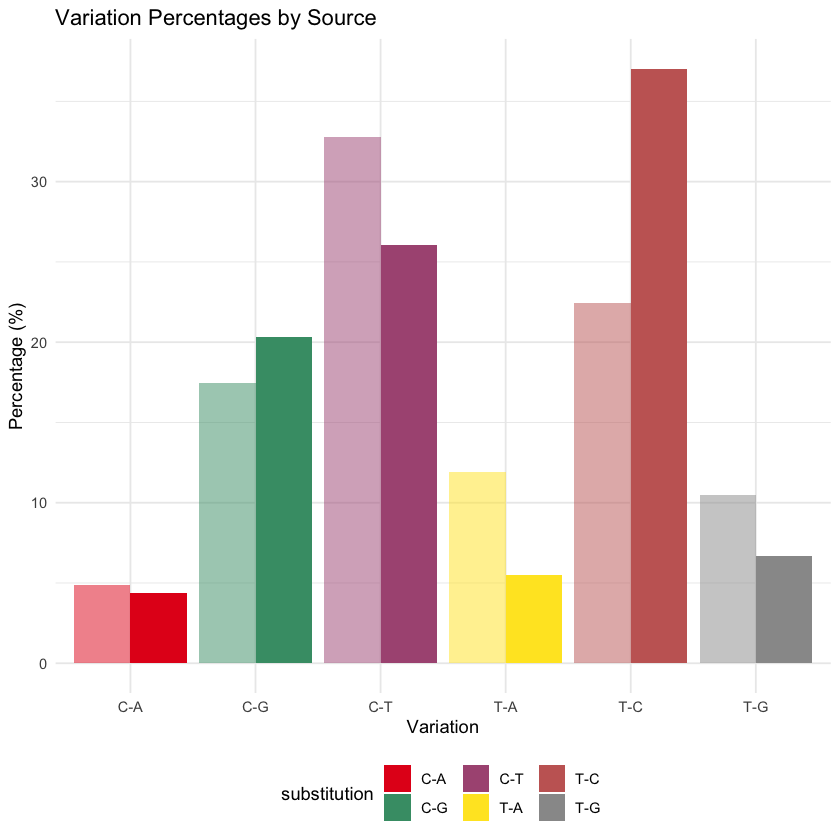

In [58]:
# Generate a color palette with as many colors as there are variation types
my_palette <- colorRampPalette(brewer.pal(9, "Set1"))(length(unique(spectro_six$substitution)))

# Create bar plot
ggplot(spectro_six, aes(x = substitution, y = Percentage, fill = substitution, alpha = source)) +
  geom_bar(stat = "identity", position = position_dodge()) +
  scale_alpha_discrete(range = c(0.5, 1), guide = "none") +
  theme_minimal() +
  labs(title = "Variation Percentages by Source", x = "Variation", y = "Percentage (%)") +
  scale_fill_manual(values = my_palette) +
  theme(legend.position = "bottom")


In [125]:
# Filter out variations that aren't present in both sources
spectro_filtered <- spectro %>%
  group_by(variation) %>%
  filter(n() > 1)

# Perform chi-square test for each variation
chi_square_results <- spectro_filtered %>%
  group_by(variation) %>%
  summarise(chisq_test_p_value = chisq.test(n)$p.value)

# Print chi-square test results
print(chi_square_results)

# A tibble: 6 × 2
  variation chisq_test_p_value
  <chr>                  <dbl>
1 A-C                 4.30e- 5
2 A-G                 1.31e-64
3 A-T                 9.31e- 1
4 C-G                 1.08e-18
5 C-T                 1.54e-14
6 G-T                 4.11e- 4


## 4. Calculate proportion FW/CDR in events

In [27]:
subregion <- df_summary %>% group_by(subregion) %>% count() %>% mutate(type = ifelse(str_detect(subregion, "^CDR"), "CDR", "FR"))
subregion

subregion,n,type
<chr>,<int>,<chr>
CDR1,152,CDR
CDR2,45,CDR
CDR3,91,CDR
FR1,284,FR
FR2,324,FR
FR3,302,FR
FR4,41,FR


In [28]:
subregion %>% group_by(type) %>% summarize(n_event=sum(n)) %>% mutate(Percentage =n_event * 100 / sum(n_event))

type,n_event,Percentage
<chr>,<int>,<dbl>
CDR,288,23.24455
FR,951,76.75545


## 5. Calculate the timing of neovariant

In [59]:
events_v3 <- readxl::read_xlsx("output/events.v3.0.xlsx")

In [60]:
events_v31 <- events_v3 %>% 
             mutate(h_from_event = log(original_umis/(original_umis+neovariant1_umis))/-0.231049) 


#### Cell count with neovariants by case

In [61]:
shm_cell_patient <- events_v31 %>% 
   group_by(Sample) %>%
   summarise(neovariant_cells = n_distinct(cell))

shm_cell_patient

Sample,neovariant_cells
<chr>,<int>
S10000,128
S11770,1
S12500,1
S13530,87
S13553,103
S144,40
S8934,4


In [62]:
# Total number of cells

print("Number of TOTAL cells with neovariants")
shm_cell_patient %>% pull(neovariant_cells) %>% sum()

[1] "Number of TOTAL cells with neovariants"


[1] 364

#### Include a numeric cell ID (n_cell_ID)

In [63]:
# Extracting the ID numbers after "S" and creating a consecutive number according to the cellbarcode
events_v31 <- events_v31 %>%
  mutate(sample_number = as.numeric(sub("S", "", Sample))) %>%
  group_by(sample_number) %>%
  mutate(n_cell_ID = paste(sample_number, dense_rank(cell), sep = ".")) %>%
  ungroup() %>%
  select(-sample_number)

In [64]:
datatable(events_v31,
        extensions = 'Buttons', 
          options = list(
            dom = 'Bfrtip',
            buttons = c('colvis'), # Button to show/hide columns
            columnDefs = list(list(targets = '_all', searchable = TRUE)) # Make all columns searchable
          ))

HTML widgets cannot be represented in plain text (need html)

In [65]:
WriteXLS::WriteXLS(events_v31,
                    "output/events.v3.1.xlsx" )

## 6. Calculate cell numbers 

In [1]:
df_seq <- read.csv("output/UMI_consensus_all.csv")
head(df_seq)

,cell,umi,nreads,ref_vdj_coverage,ref_cdr_coverage,consensus,aligned_consensus,depths,subject
,<chr>,<chr>,<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>
1,AAACCTGAGTGTTTGC,AATTGACGCG,174,1,1,TTTCTTATATGGGGGCTCTGGGAGACGAGCCCAGCACTGGAAGTCGCCGGTGTTTCCATTCGGTGATCATCACTGAATACAGAGGACTCACCATGGAGTTTGGGCTGAACTGGGTTCTCCTCGTTGCTCTTTTAAGAGGTGTCCAGTGTCAGGTGCAACTGGTGGAGTCTGGGGGAGACGTGGTCCAGCCTGGGAGGTCCCTGCGACTCAGCTGTTCAGCCTCTACTTTCACCTTCAACTCTTATACTATGCACTGGGTCCGCCAGGCTCCAGGCAAGGGGCCGGAGTGGGTGGCACTTATATCAGATAATGGATACACTTTATACTACGCCGACTCCGTGAGGGGCCGATTCACCGTCTCCAGAGACAATTCCAAGAACACCCTATATCTTCAAATGAACAGCCTAAGAGCTGAGGACACGGCTGTCTATTACTGTGCGACCAACTCCTCATTAAGTCGATATTATTATTTGGACGTCTGGGGCAGAGGCACCACGGTCACCGTCTCCACAGGGAGTGCATCCGCCCCAACCCTTTTC,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNTTTCTTATATGGGGGCTCTGGGAGACGAGCCCAGCACTGGAAGTCGCCGGTGTTTCCATTCGGTGATCATCACTGAATACAGAGGACTCACCATGGAGTTTGGGCTGAACTGGGTTCTCCTCGTTGCTCTTTTAAGAGGTGTCCAGTGTCAGGTGCAACTGGTGGAGTCTGGGGGAGACGTGGTCCAGCCTGGGAGGTCCCTGCGACTCAGCTGTTCAGCCTCTACTTTCACCTTCAACTCTTATACTATGCACTGGGTCCGCCAGGCTCCAGGCAAGGGGCCGGAGTGGGTGGCACTTATATCAGATAATGGATACACTTTATACTACGCCGACTCCGTGAGGGGCCGATTCACCGTCTCCAGAGACAATTCCAAGAACACCCTATATCTTCAAATGAACAGCCTAAGAGCTGAGGACACGGCTGTCTATTACTGTGCGACCAACTCCTCATTAAGTCGATATTATTATTTGGACGTCTGGGGCAGAGGCACCACGGTCACCGTCTCCACAGGGAGTGCATCCGCCCCAACCCTTTTCNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;15;15;15;15;15;15;16;16;16;16;16;16;16;16;17;105;106;106;107;109;109;111;112;114;114;114;114;116;117;120;120;123;123;123;123;123;124;124;126;126;126;126;127;127;127;127;128;128;128;128;128;128;128;128;129;128;127;127;127;127;127;128;128;129;129;129;129;129;130;130;130;130;130;129;129;131;131;131;132;132;132;132;129;129;129;129;131;129;129;129;130;130;129;129;129;129;129;128;128;127;125;123;122;122;122;119;118;118;118;118;117;115;115;115;114;115;113;113;113;112;41;43;44;44;44;45;44;45;45;45;45;45;46;46;45;45;45;45;45;46;45;45;45;44;44;45;44;43;43;43;43;43;44;44;45;45;45;44;44;44;43;43;41;40;40;40;40;40;39;38;37;37;34;34;34;34;34;34;35;34;34;34;34;33;33;33;33;32;32;32;33;33;33;33;33;33;33;33;33;33;33;33;33;33;31;32;32;33;33;33;33;33;33;33;33;33;31;31;30;28;28;28;29;29;29;29;29;27;26;26;26;25;25;25;26;25;25;25;25;25;25;25;25;25;25;25;25;25;25;25;25;25;25;25;25;26;24;24;24;23;23;23;22;21;21;21;20;20;19;19;20;20;20;20;20;19;19;19;18;18;17;17;17;16;16;16;15;15;15;15;14;14;14;13;13;12;12;12;12;12;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;10;10;10;10;10;10;10;10;10;10;10;10;9;9;8;8;8;8;8;8;8;8;8;8;7;7;7;6;6;5;5;5;5;5;5;5;5;6;7;7;7;7;7;7;6;6;6;6;6;6;6;6;6;6;6;6;5;5;5;5;5;5;5;5;6;6;6;6;6;6;6;6;6;6;6;6;6;5;5;6;6;6;6;6;6;6;6;6;6;6;6;6;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;3;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,K1B_S10000-HC
2,AAACCTGGTCCAGTAT,ACCTCGAATG,109,1,1,ATTCGGTGATCATCACTGAACACAGAGGACTCACCATGGAGTTTGGGCTGAACTGGGTTCTCCTCGTTGCTCTTTTAAGAGGTGTCC

In [15]:
case_cell <- df_seq %>% 
   mutate(Patient_id = str_extract(subject, "(?<=_)[^_]+(?=-)"),diagnosis = case_when(subject %like% "K%" ~ "FL",
                         subject %like% "Q%" ~ "CLL",
                          TRUE ~ NA)) %>%
  mutate(experiment =sub("_(.*)$", "", subject)) %>%
   group_by(diagnosis,Patient_id,experiment) %>%
    summarise(total_cell = n_distinct(cell)) %>%
    replace(is.na(.), 0) 
case_cell

`summarise()` has grouped output by 'diagnosis', 'Patient_id'. You can override using the `.groups` argument.


diagnosis,Patient_id,experiment,total_cell
<chr>,<chr>,<chr>,<int>
CLL,S356,Q2,1027
CLL,S4725,Q2,1112
CLL,S5714,Q1,1069
CLL,S7482,Q1,644
CLL,S9856,Q2,587
FL,S10000,K1B,1614
FL,S10000,K7B,7343
FL,S10971,K1B,1089
FL,S11770,K2B,215


## 7. Incorporate Syn/NonSyn data (Check problem of UMIS with NA)

In [2]:
events_v31 <- readxl::read_xlsx("output/events.v3.1.xlsx")

In [3]:
## Load all SHMss events detected (positive + false positive)
df <- Sys.glob("input/results_20230912/FL/*/*.csv") %>%
  purrr::map_dfr(function(x) {
    readr::read_csv(x, col_types = "ccicccilciicccccc", progress = FALSE) %>%
      dplyr::mutate(subject = gsub("^.*/|\\.shm.*$", "", x))
  })

Warning message:
“One or more parsing issues, call `problems()` on your data frame for details, e.g.:
  dat <- vroom(...)
  problems(dat)”


In [4]:
options(repr.matrix.max.cols=50, repr.matrix.max.rows=100)
events_v32 <- events_v31 %>% left_join(df %>% select(subject,cell,subregion,position,codon_cc,aa_ref_cc,aa_alt_cc,nucl,context_cc,nucl_po), by=c("subject","cell","subregion","position")) %>% unique() %>% 
mutate(aminoacid_original=if_else(nucl == original,aa_alt_cc,NA)) %>% 
mutate(aminoacid_n1=if_else(nucl == neovariant1,aa_alt_cc,NA)) %>%
mutate(aminoacid_n2=if_else(nucl == neovariant2,aa_alt_cc,NA)) %>%
 group_by(order,Chip,Sample,`Ig Chain`,	`V(D)Jmutations`,	`VDJmutations`,
          `VJmutations`,`inBoth`,`Cell ident`,subject,cell,subregion,position,vgene_position_aligned,
          context_po,context_cc,nucl_po,original,neovariant1,neovariant2,original_umis,neovariant1_umis,neovariant2_umis,productive,h_from_event,n_cell_ID,codon_cc) %>%
  summarise(
    aminoacid_original = na.omit(aminoacid_original)[1],
    aminoacid_n1 = na.omit(aminoacid_n1)[1],
    aminoacid_n2 = na.omit(aminoacid_n2)[1],
    .groups = 'drop' # to drop the grouping after summarising
  ) %>% mutate(
    mutation_type = case_when(
      aminoacid_original == aminoacid_n1 ~ "silent",
      (!is.na(aminoacid_original)) & aminoacid_n1 == "*" ~ "nonsense",
      aminoacid_original == "*" ~ "stop-loss",
      aminoacid_original != aminoacid_n1 ~ "missense",
      TRUE ~ NA_character_
    )
  )

### 8. Include modifications to master table like:
 - Generate full context (5 nt) 
 - Generate a full context (5 nt) for every neovariant 1 and 2 when there is not original
 - Calculate again the AID motif now using the cell context
- Define in which strand it was found the motif
 - Identify if the motif are destroyed with the neovariant

In [30]:
#events_v33 <- readxl::read_xlsx("output/events.v3.1.xlsx")

In [6]:
# Generate full context (5 nt) and also with context_cc
events_v33 <- events_v32 %>%
              mutate(nucl_po = toupper(nucl_po)) %>% mutate(context_po_coding_strand = stri_replace_first_fixed(context_po, ".", nucl_po)) %>% 
              mutate(context_cc_po = stri_replace_first_fixed(context_cc, ".", original)) %>% 
              mutate(variation_delete = case_when(is.na(original) ~ NA, !is.na(original) ~ paste0(original,"-",neovariant1))) %>% 
              mutate(variation_delete2 = case_when(is.na(original) ~ paste0(neovariant1,"-",neovariant2), !is.na(original) ~ NA))

In [7]:
# # Incorporate cell context for neovariant1 and neovariant2
# events_v33 <- events_v33 %>% mutate(context_cc_neo1 = case_when(is.na(original) ~ stri_replace_first_fixed(context_cc, ".", neovariant1),
#                                               TRUE ~ NA )) %>% 
#                mutate(context_cc_neo2 = case_when(is.na(original) ~ stri_replace_first_fixed(context_cc, ".", neovariant2),
#                                               TRUE ~ NA ))

In [8]:
head(events_v33)

order,Chip,Sample,Ig Chain,V(D)Jmutations,VDJmutations,VJmutations,inBoth,Cell ident,subject,cell,subregion,position,vgene_position_aligned,context_po,context_cc,nucl_po,original,neovariant1,neovariant2,original_umis,neovariant1_umis,neovariant2_umis,productive,h_from_event,n_cell_ID,codon_cc,aminoacid_original,aminoacid_n1,aminoacid_n2,mutation_type,context_po_coding_strand,context_cc_po,variation_delete,variation_delete2,context_cc_neo1,context_cc_neo2
<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,K7B,S10000,L,1,0,1,FALSE,S10000.1,K7B_S10000-LC,AAAGATGGTCCGAGTC,FR1,136,28,CA.TG,NA,G,G,C,NA,45,79,NA,TRUE,4.387031,10000.1,NA,NA,NA,NA,NA,CAGTG,NA,G-C,NA,NA,NA
2,K7B,S10000,H,4,4,0,FALSE,S10000.1,K7B_S10000-HC,AAAGCAAGTTCAGACT,FR3,307,183,GC.GA,GC.GA,A,A,C,NA,21,16,NA,TRUE,2.451408,10000.2,GCX,A,A,NA,silent,GCAGA,GCAGA,A-C,NA,NA,NA
3,K7B,S10000,H,4,4,0,FALSE,S10000.2,K7B_S10000-HC,AAAGCAAGTTCAGACT,FR3,361,237,CT.TA,CT.TA,G,G,C,NA,16,14,NA,TRUE,2.720672,10000.2,CTX,L,L,NA,silent,CTGTA,CTGTA,G-C,NA,NA,NA
4,K7B,S10000,H,4,4,0,FALSE,S10000.3,K7B_S10000-HC,AAAGCAAGTTCAGACT,FR3,382,258,CT.AG,CT.AG,G,NA,A,C,NA,12,13,TRUE,NA,10000.2,CTX,NA,L,L,NA,CTGAG,NA,NA,A-C,CTAAG,CTCAG
5,K7B,S10000,H,4,4,0,FALSE,S10000.4,K7B_S10000-HC,AAAGCAAGTTCAGACT,FR3,391,267,GA.GA,GA.GA,G,G,C,NA,12,14,NA,TRUE,3.346433,10000.2,GAX,E,D,NA,missense,GAGGA,GAGGA,G-C,NA,NA,NA
6,K7B,S10000,L,3,0,3,FALSE,S10000.1,K7B_S10000-LC,AAAGTAGAGGGTTTCT,FR1,153,45,GG.CA,NA,G,G,A,NA,16,39,NA,TRUE,5.344081,10000.3,NA,NA,NA,NA,NA,GGGCA,NA,G-A,NA,NA,NA


### Identify AID motifs

In [41]:
# Modification of AID motif to identify motif forward and reverse
aidp2 <- list(
  # Canonical AID signature should be C>T/G RCY
  WRCY = c(f = c(m = "C-[TGA]", c = "[AT][AG].[CT].")), #WRCY (forw) and RGYW (Rev)
  # non-canonical according to Kasar A>C at WA
  WA = c(f = c(m = "A-[TGC]", c = ".[AT].[ACGT].")),
  # signature 9 accordign to Alexandrov C>T at N.G
  RCG = c(f = c(m = "C-[TGA]", c = ".[AG].G."))
)

In [42]:
# Function to get reverse complement, handles NA
get_rev_comp <- function(s) {
  if (is.na(s)) return(NA)
  dna_s <- DNAString(s)
  return(as.character(reverseComplement(dna_s)))
}

# Custom function to get complement without reversing
get_complement <- function(seq) {
  # Define the complement mapping
  complement_map <- c("A" = "T", "T" = "A", "G" = "C", "C" = "G", "-" = "-", "N" = "N")
  
  # Convert sequence string to character vector
  seq_vector <- strsplit(seq, '')[[1]]
  
  # Find the complement using the mapping
  complement_vector <- complement_map[seq_vector]
  
  # Convert back to a single string
  complement_seq <- paste0(complement_vector, collapse = "")
  
  return(complement_seq)
}

In [39]:
identify_aid_patterns_bystrand <- function(mutation, context, aid_patterns = aidp2) {
      matches <- names(aid_patterns)[sapply(aid_patterns, function(p) {
        (grepl(p["f.m"], mutation) & grepl(p["f.c"], context))
      })]
    
      if (length(matches) == 1) {
        return(matches)
      }
      else if (length(matches) == 0) {
        return("None")
      }
      else {
        print("Problem!")
      }
    }

In [43]:
#Define AID motifs from consensus cell context (only for variation where is possible to define hierarchy)
events_v33$original_aid_motif1 <- mapply(identify_aid_patterns_bystrand, events_v33$variation_delete, events_v33$context_cc)
events_v33$original_aid_motif2 <- mapply(identify_aid_patterns_bystrand, sapply(events_v33$variation_delete, get_complement), sapply(events_v33$context_cc, get_rev_comp))

events_v33$neovariant_aid_motif1 <- mapply(identify_aid_patterns_bystrand, sapply(events_v33$variation_delete, reverse), events_v33$context_cc)
events_v33$neovariant_aid_motif2 <- mapply(identify_aid_patterns_bystrand, sapply(sapply(events_v33$variation_delete, reverse),get_complement), sapply(events_v33$context_cc, get_rev_comp))

In [44]:
#Define AID motifs from consensus cell context when there is not original nucleotide

# AID patterns; f/r = forward/reverse, m/c = mutation/context
aidp <- list(
  # Canonical AID signature should be C>T/G RCY
  WRCY = c(f = c(m = "C-[TGA]", c = "[AT][AG].[CT]."), r = c(m = "G-[ACT]", c = ".[AG].[CT][AT]")), #WRCY (forw) and RGYW (Rev)
  # non-canonical according to Kasar A>C at WA
  WA = c(f = c(m = "A-[TGC]", c = ".[AT].[ACGT]."), r = c(m = "T-[CGA]", c = ".[ACGT].[AT].")),
  # signature 9 accordign to Alexandrov C>T at N.G
  RCG = c(f = c(m = "C-[TGA]", c = ".[AG].G."), r = c(m = "G-[ACT]", c = ".C.[CT]."))
)

identify_aid_patterns <- function(mutation, context, aid_patterns = aidp) {
      matches <- names(aid_patterns)[sapply(aid_patterns, function(p) {
        (grepl(p["f.m"], mutation) & grepl(p["f.c"], context)) |
          (grepl(p["r.m"], mutation) & grepl(p["r.c"], context))
      })]
    
      if (length(matches) == 1) {
        return(matches)
      }
      else if (length(matches) == 0) {
        return("None")
      }
      else {
        print("Problem!")
      }
    }

reverse_string <- function(x) {
  if (is.na(x)) {
    return(NA)
  }
  elements <- strsplit(x, "-")[[1]]
  reversed_elements <- rev(elements)
  return(paste(reversed_elements, collapse = "-"))
}

# Calculate AID motif for context cc with neovariant 1 or neovariant 2
events_v33$neovariant_1_aid_motif <- mapply(identify_aid_patterns, events_v33$variation_delete2, events_v33$context_cc)
events_v33$neovariant_2_aid_motif <- mapply(identify_aid_patterns, sapply(events_v33$variation_delete2, reverse_string), events_v33$context_cc)

In [57]:
# Rank motifs
events_v33 <- events_v33 %>% 
  mutate(original_aid_motif = case_when(
    original_aid_motif1 == "WRCY" | original_aid_motif2 == "WRCY" ~ "WRCY",
    original_aid_motif1 == "WA" | original_aid_motif2 == "WA" ~ "WA",
    original_aid_motif1 == "RCG" | original_aid_motif2 == "RCG" ~ "RCG",
    original_aid_motif1 == "None" | original_aid_motif2 == "None" ~ "None",
    TRUE ~ NA
  )) %>%  
    mutate(neovariant_aid_motif = case_when(
    neovariant_aid_motif1 == "WRCY" | neovariant_aid_motif2 == "WRCY" ~ "WRCY",
    neovariant_aid_motif1 == "WA" | neovariant_aid_motif2 == "WA" ~ "WA",
    neovariant_aid_motif1 == "RCG" | neovariant_aid_motif2 == "RCG" ~ "RCG",
    neovariant_aid_motif1 == "None" | neovariant_aid_motif2 == "None" ~ "None",
    TRUE ~ NA
  )) %>% 
  mutate(motif_destroyed = case_when(
    original_aid_motif == "None" & neovariant_aid_motif == "None" ~ "No_motif",
    original_aid_motif == neovariant_aid_motif ~ "FALSE",
    is.na(variation_delete) ~ "No_evaluated",
    !is.na(original_aid_motif) & is.na(neovariant_aid_motif) ~ "TRUE",
    original_aid_motif != neovariant_aid_motif ~ "TRUE",
    is.na(original_aid_motif) ~ "No_motif",
    TRUE ~ "Other" # catches all other cases, can be removed if not needed
  ))  %>%
  mutate(strand_of_motif = case_when(
    original_aid_motif1 != "None" ~ "coding",
    original_aid_motif2 != "None" ~ "non-coding",
    is.na(original) ~ "Not_evaluated",
    original_aid_motif1 == "None" & original_aid_motif2 == "None" ~ "No-motif",
    TRUE ~ "Other"  # For any other cases, can be removed if not needed
   ))

In [63]:
options(repr.matrix.max.cols=50, repr.matrix.max.rows=100)
events_v33 %>% select(-context_po_coding_strand,-variation_delete,-variation_delete2,-context_cc_neo1,-context_cc_neo2,-original_aid_motif1,-original_aid_motif2,-neovariant_aid_motif1,-neovariant_aid_motif2,
                      -context_po,-context_cc)

order,Chip,Sample,Ig Chain,V(D)Jmutations,VDJmutations,VJmutations,inBoth,Cell ident,subject,cell,subregion,position,vgene_position_aligned,nucl_po,original,neovariant1,neovariant2,original_umis,neovariant1_umis,neovariant2_umis,productive,h_from_event,n_cell_ID,codon_cc,aminoacid_original,aminoacid_n1,aminoacid_n2,mutation_type,context_cc_po,neovariant_1_aid_motif,neovariant_2_aid_motif,original_aid_motif,neovariant_aid_motif,motif_destroyed,strand_of_motif
<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,K7B,S10000,L,1,0,1,FALSE,S10000.1,K7B_S10000-LC,AAAGATGGTCCGAGTC,FR1,136,28,G,G,C,NA,45,79,NA,TRUE,4.387031,10000.1,NA,NA,NA,NA,NA,NA,None,None,None,None,No_motif,No-motif
2,K7B,S10000,H,4,4,0,FALSE,S10000.1,K7B_S10000-HC,AAAGCAAGTTCAGACT,FR3,307,183,A,A,C,NA,21,16,NA,TRUE,2.451408,10000.2,GCX,A,A,NA,silent,GCAGA,None,None,None,None,No_motif,No-motif
3,K7B,S10000,H,4,4,0,FALSE,S10000.2,K7B_S10000-HC,AAAGCAAGTTCAGACT,FR3,361,237,G,G,C,NA,16,14,NA,TRUE,2.720672,10000.2,CTX,L,L,NA,silent,CTGTA,None,None,None,None,No_motif,No-motif
4,K7B,S10000,H,4,4,0,FALSE,S10000.3,K7B_S10000-HC,AAAGCAAGTTCAGACT,FR3,382,258,G,NA,A,C,NA,12,13,TRUE,NA,10000.2,CTX,NA,L,L,NA,NA,WA,None,None,None,No_motif,Not_evaluated
5,K7B,S10000,H,4,4,0,FALSE,S10000.4,K7B_S10000-HC,AAAGCAAGTTCAGACT,FR3,391,267,G,G,C,NA,12,14,NA,TRUE,3.346433,10000.2,GAX,E,D,NA,missense,GAGGA,None,None,None,RCG,TRUE,No-motif
6,K7B,S10000,L,3,0,3,FALSE,S10000.1,K7B_S10000-LC,AAAGTAGAGGGTTTCT,FR1,153,45,G,G,A,NA,16,39,NA,TRUE,5.344081,10000.3,NA,NA,NA,NA,NA,NA,None,None,None,None,No_motif,No-motif
7,K7B,S10000,L,3,0,3,FALSE,S10000.2,K7B_S10000-LC,AAAGTAGAGGGTTTCT,FR1,174,66,C,C,T,NA,16,39,NA,TRUE,5.344081,10000.3,NA,NA,NA,NA,NA,NA,None,None,None,None,No_motif,No-motif
8,K7B,S10000,L,3,0,3,FALSE,S10000.3,K7B_S10000-LC,AAAGTAGAGGGTTTCT,CDR1,185,77,G,G,A,NA,38,15,NA,TRUE,1.439979,10000.3,NA,NA,NA,NA,NA,NA,None,None,None,None,No_motif,No-motif
9,K7B,S10000,H,3,3,0,FALSE,S10000.1,K7B_S10000-HC,AAATGCCTCGAGGTAG,CDR2,291,174,A,A,G,NA,29,14,NA,TRUE,1.704852,10000.4,TTX,L,L,NA,silent,TTATA,None,None,WA,None,TRUE,coding


## 3. Substitution type (spectro)

### Six Substituion pattern of all variant in 10x data

In [3]:
#clonotype information for K45678B
clonotype <- read.csv("~/repositories/FL_10X_2/250_Clonotypes/outs/clones_2022_01_18.csv") %>% mutate(cell = gsub(".{2}$", "", barcode)) %>% 
 #            select(source, cell,chain,is_cell,productive,high_confidence,umis,reads,seqConcClone, ,cluster,seqConcCount)  %>% 
             mutate(gene=case_when(chain == "IGH" ~ "HC",
                                     chain == "IGK" | chain == "IGL" ~ "LC",
                                    TRUE ~ "NA"))

In [10]:
#clonotype information for K123B
clonotype_K13B <- read.csv("~/repositories/FL_10X_2/250_Clonotypes/outs/clonesMulti_2022_06_09.csv") %>% mutate(source=paste0(source,"_",subject))

In [4]:
# default pairwise alignment
# to use for variable tasks
pairwiseAlignmentPreset <- function( pattern, subject, score ) {
  alignment <- pairwiseAlignment( pattern = pattern,
                                  subject = subject,
                                  type = "local",
                                  substitutionMatrix = nucleotideSubstitutionMatrix( match = 1,
                                                                                     mismatch = 0,
                                                                                     baseOnly = FALSE ),
                                  gapOpening = 5,
                                  gapExtension = 2,
                                  scoreOnly = score )
  return( alignment ) }


# # for K45678B 

# d<- read_csv( "~/repositories/FL_10X_2/250_Clonotypes/outs/clones_2022_01_18.csv" ) %>%
#      filter( source == "K4B" )

# po <- d %>% filter( contigId %like% "PO",chain == "IGH") %>% pull( seq )


# test <- d %>%
#     filter( seqClone == 1,
#     chain == "IGH" ) %>%
#     pull( seq ) %>%
#     unique()

# al<- pairwiseAlignmentPreset( toupper( po ),
#     toupper( test ),
#     score = FALSE )

# mm <- al@pattern@mismatch@unlistData

# subst <- sapply( 1: length( mm ),
#         function( i ){
#         list( substr( po, mm[ i ], mm[ i ]),
#         substr( test, mm[ i ], mm[ i ]) )
#         }) #%>% as.data.frame()

# colnames( subst ) <- mm

# subst <- subst %>% t() %>%
#          as.data.frame() %>%
#         rownames_to_column( var = "pos" ) %>%
#         mutate( subst = paste0( V1,"-", V2 ) )

In [6]:
perform_alignment_analysis <- function(input_df, output_file = "final_output_distinct.csv",
                                       source_col = 'source', chain_col = 'chain', seqClone_col = 'seqClone',
                                       contigId_col = 'contigId', seq_col = 'seq', score = FALSE) {
  # Initialize an empty data frame to store results
  final_output <- data.frame()
  
  # Fetch unique sources and chains
  unique_sources <- unique(input_df[[source_col]])
  unique_chains <- unique(input_df[[chain_col]])
  
  # Iterate over each unique source, chain, and seqClone
  for (src in unique_sources) {
    for (chn in unique_chains) {
      
      # Fetch the reference sequence (seqClone == 0 and contigId == "PO")
      ref_seq <- subset(input_df, input_df[[source_col]] == src & 
                                  input_df[[chain_col]] == chn & 
                                  input_df[[seqClone_col]] == 0 & 
                                  input_df[[contigId_col]] %like% "PO")[[seq_col]]
      
      if (length(ref_seq) == 0) next # Skip if no reference sequence
      
      # Fetch unique seqClone values, ignoring NA
      seqClones <- na.omit(unique(subset(input_df, input_df[[source_col]] == src & 
                                                  input_df[[chain_col]] == chn)[[seqClone_col]]))
      
      for (scl in seqClones) {
        if (scl == 0) next # Skip reference seqClone
        
        # Fetch the test sequence (ignoring NA and taking only the first sequence for each seqClone)
        test_seq <- na.omit(subset(input_df, input_df[[source_col]] == src & 
                                             input_df[[chain_col]] == chn & 
                                             input_df[[seqClone_col]] == scl)[[seq_col]])[1]
        
        # Perform the alignment
        alignment <- pairwiseAlignmentPreset(toupper(ref_seq), toupper(test_seq), score = score)
        
        # Extract the mismatch positions and bases
        mm <- alignment@pattern@mismatch@unlistData
        subst <- sapply(1:length(mm), function(i) {
          list(substr(ref_seq, mm[i], mm[i]), substr(test_seq, mm[i], mm[i]))
        })
        
        # Format and store the results
        if (length(mm) == 0) next # Skip if no mismatches
        colnames(subst) <- mm
        subst <- as.data.frame(t(subst))
        rownames(subst) <- mm
        subst$pos <- rownames(subst)
        subst$subst <- paste0(subst$V1, "-", subst$V2)
        subst[[source_col]] <- src
        subst[[seqClone_col]] <- scl
        
        # Append to final output
        final_output <- rbind(final_output, subst)
      }
    }
  }
  
  final_output_distinct <- final_output %>%
    distinct(pos, source, subst, .keep_all = TRUE)
  
  # Export the final output
  if (nrow(final_output_distinct) > 0) {
    write.csv(final_output_distinct[, c("pos", "subst", source_col, seqClone_col)], output_file, row.names=FALSE)
  } else {
    print("Final output is empty.")
  }
}


In [12]:
# Example usage
perform_alignment_analysis(clonotype, output_file = "output/final_output_distinct_K45678B.csv", source_col = "source")

In [11]:
# Example usage
perform_alignment_analysis(clonotype_K13B, output_file = "output/final_output_distinct_K123B.csv", source_col = "source")

In [4]:
K123B_subs <- read_csv("output/final_output_distinct_K123B.csv") %>% mutate(subst = toupper(subst))

Rows: 4515 Columns: 4
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (2): subst, source
dbl (2): pos, seqClone

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [5]:
K45678B_subs <- read_csv("output/final_output_distinct_K45678B.csv") %>% mutate(subst = toupper(subst))

Rows: 2953 Columns: 4
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (2): subst, source
dbl (2): pos, seqClone

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [6]:
six_pattern <- function(df, case_col, output_df_name) {
  case_col_sym <- sym(case_col)

  
  df_transformed <- df %>%
    mutate(
      substitution = case_when(
        !!case_col_sym == "G-T" ~ "C-A",
        !!case_col_sym == "G-C" ~ "C-G",
        !!case_col_sym == "G-A" ~ "C-T",
        !!case_col_sym == "A-T" ~ "T-A",
        !!case_col_sym == "A-G" ~ "T-C",
        !!case_col_sym == "A-C" ~ "T-G",
        TRUE ~ as.character(!!case_col_sym)
      )
    ) %>% filter(!substitution %in% c("A-A","C-C","G-G","T-T"))
  
  assign(output_df_name, df_transformed, envir = .GlobalEnv)
}

In [7]:
KBall_subs <- K123B_subs %>% bind_rows(K45678B_subs) %>% mutate(
    source = case_when(
      source == "K4B" ~ "K4B_S8934",
      source == "K5B" ~ "K5B_S8934",
      source == "K6B" ~ "K6B_S13530",
      source == "K7B" ~ "K7B_S10000",
      source == "K8B" ~ "K8B_S13553",
      TRUE ~ source
    )) 

six_pattern(
  KBall_subs, 
  case_col = "subst", 
  output_df_name = "KBall_subs_six_pattens"
)

### Group substitution by subject

In [15]:
KBall_subs_subject <- KBall_subs_six_pattens %>% group_by(source,substitution) %>% count() %>% group_by(source) %>% mutate(Percentage =n * 100 / sum(n)) %>%
                      dplyr::rename(subject=source) %>% mutate(source = "10x_bulk") 
head(KBall_subs_subject,12)

subject,substitution,n,Percentage,source
<chr>,<chr>,<int>,<dbl>,<chr>
K1B_S10000,C-A,45,10.613208,10x_bulk
K1B_S10000,C-G,83,19.575472,10x_bulk
K1B_S10000,C-T,132,31.132075,10x_bulk
K1B_S10000,T-A,48,11.320755,10x_bulk
K1B_S10000,T-C,67,15.801887,10x_bulk
K1B_S10000,T-G,49,11.556604,10x_bulk
K1B_S10971,C-A,12,8.571429,10x_bulk
K1B_S10971,C-G,25,17.857143,10x_bulk
K1B_S10971,C-T,41,29.285714,10x_bulk


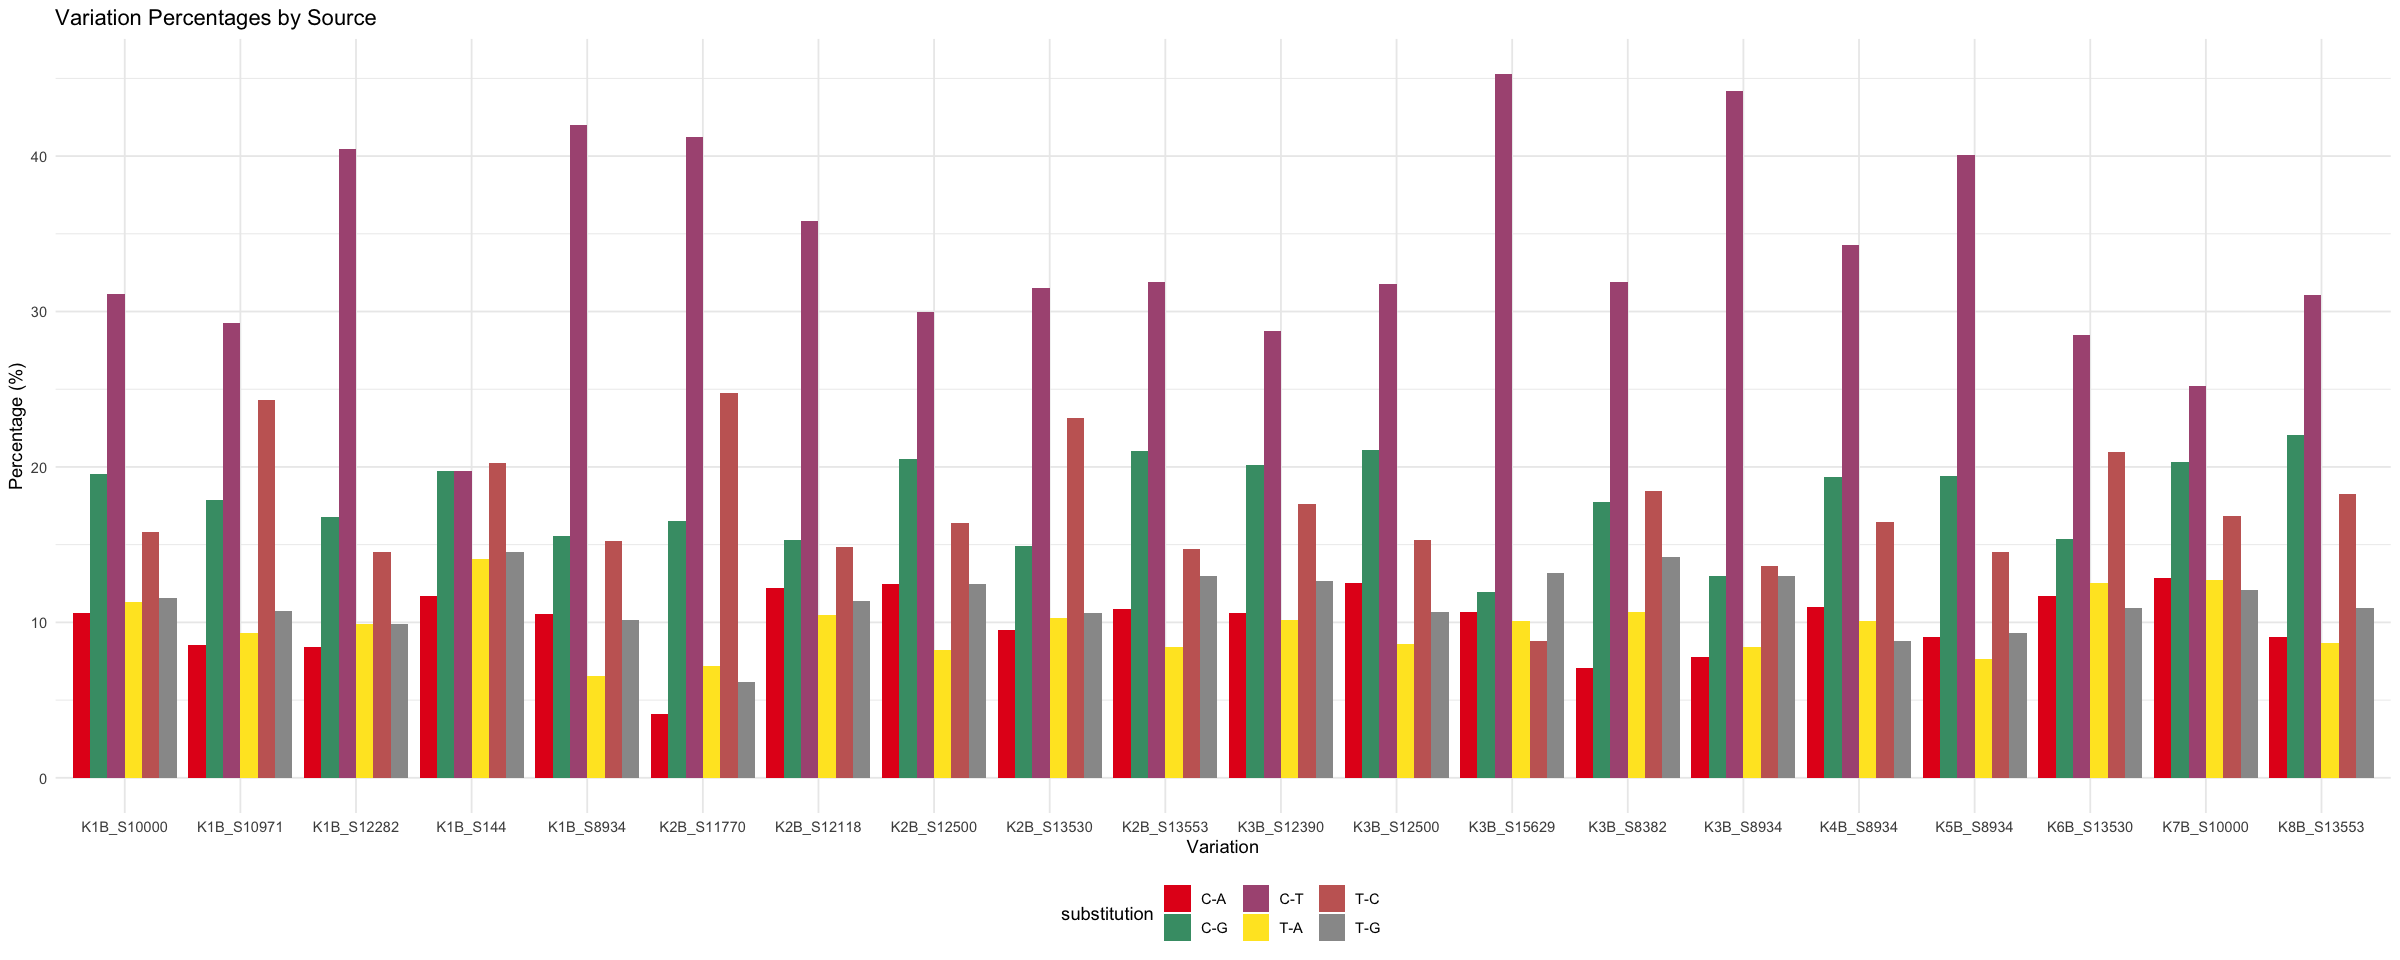

In [19]:
# Set plot dimensions
options(repr.plot.width=20, repr.plot.height=8)

# Generate a color palette with as many colors as there are variation types
my_palette <- colorRampPalette(brewer.pal(9, "Set1"))(length(unique(KBall_subs_subject$substitution)))

# Create bar plot
ggplot(KBall_subs_subject, aes(x = subject, y = Percentage, fill = substitution)) +
  geom_bar(stat = "identity", position = position_dodge()) +
  theme_minimal() +
  labs(title = "Variation Percentages by Source", x = "Variation", y = "Percentage (%)") +
  scale_fill_manual(values = my_palette) +
  theme(legend.position = "bottom")


### Overall substituion

In [20]:
#data neovariant
# remove variation where we can not define hierarchy
spectro <- events_v33 %>% filter(!is.na(variation_delete)) %>% mutate(subject=str_replace(subject, "-[^-]+$", "")) 
                    
# transform substituion to six pattern
six_pattern(
  spectro, 
  case_col = "variation_delete", 
  output_df_name = "spectro"
)

spectro_subject <- spectro %>% group_by(subject,substitution) %>% count() %>% group_by(subject) %>% mutate(Percentage =n * 100 / sum(n)) %>% mutate(source = "neoavariants")
spectro_summary <- spectro %>% group_by(substitution) %>% count() %>% ungroup() %>% mutate(Percentage =n * 100 / sum(n)) %>% mutate(source = "neoavariants") %>% dplyr::rename(total_n=n) %>% select(source,everything()) 


In [21]:
# data from muational signature filter by the subject used in 10x
mutations_ig <- mutations_ig %>%filter(!sample %in% c('FL_10000_LN','FL_10971_LN','FL_11770_LN','FL_12118_LN','FL_12282_LN','FL_8934_LN','FL_8934_PBL')) 

# transform substituion to six pattern
six_pattern(
  mutations_ig, 
  case_col = "variation", 
  output_df_name = "mutations_ig_spectro"
)

#Summary data by substitution
mutations_ig_spectro <- mutations_ig_spectro %>% group_by(substitution) %>% count() %>% ungroup() %>% mutate(Percentage =n * 100 / sum(n)) %>% 
mutate(source = "Ig_WES") %>% dplyr::rename(total_n=n) %>% select(source,everything()) 

In [22]:
# data sanger Marcelo
# transform substituion to six pattern
six_pattern(
  mutations_ig_m, 
  case_col = "variation", 
  output_df_name = "mutations_ig_m_spectro"
)

# #Summary data by substitution
mutations_ig_m_spectro <- mutations_ig_m_spectro %>% group_by(substitution) %>% filter(substitution %in% mutations_ig_spectro$substitution) %>% 
                          count() %>% ungroup() %>% mutate(Percentage =n * 100 / sum(n)) %>% 
                        mutate(source = "Ig_sanger") %>% dplyr::rename(total_n=n) %>% select(source,everything()) 

In [23]:
#combine 4 data source 10x_bulk,spectro_summary,mutations_ig_spectro,mutations_ig_m_spectro

spectro_combine <- KBall_subs_six_pattens %>% group_by(substitution) %>% count() %>% ungroup() %>% mutate(Percentage =n * 100 / sum(n)) %>% 
               mutate(source="10x_bulk") %>% dplyr::rename(total_n=n) %>% select(source,everything()) %>%
               bind_rows(spectro_summary,mutations_ig_spectro,mutations_ig_m_spectro )

In [24]:
head(spectro_combine)

source,substitution,total_n,Percentage
<chr>,<chr>,<int>,<dbl>
10x_bulk,C-A,807,10.81914
10x_bulk,C-G,1388,18.60839
10x_bulk,C-T,2351,31.51897
10x_bulk,T-A,760,10.18903
10x_bulk,T-C,1304,17.48224
10x_bulk,T-G,849,11.38222


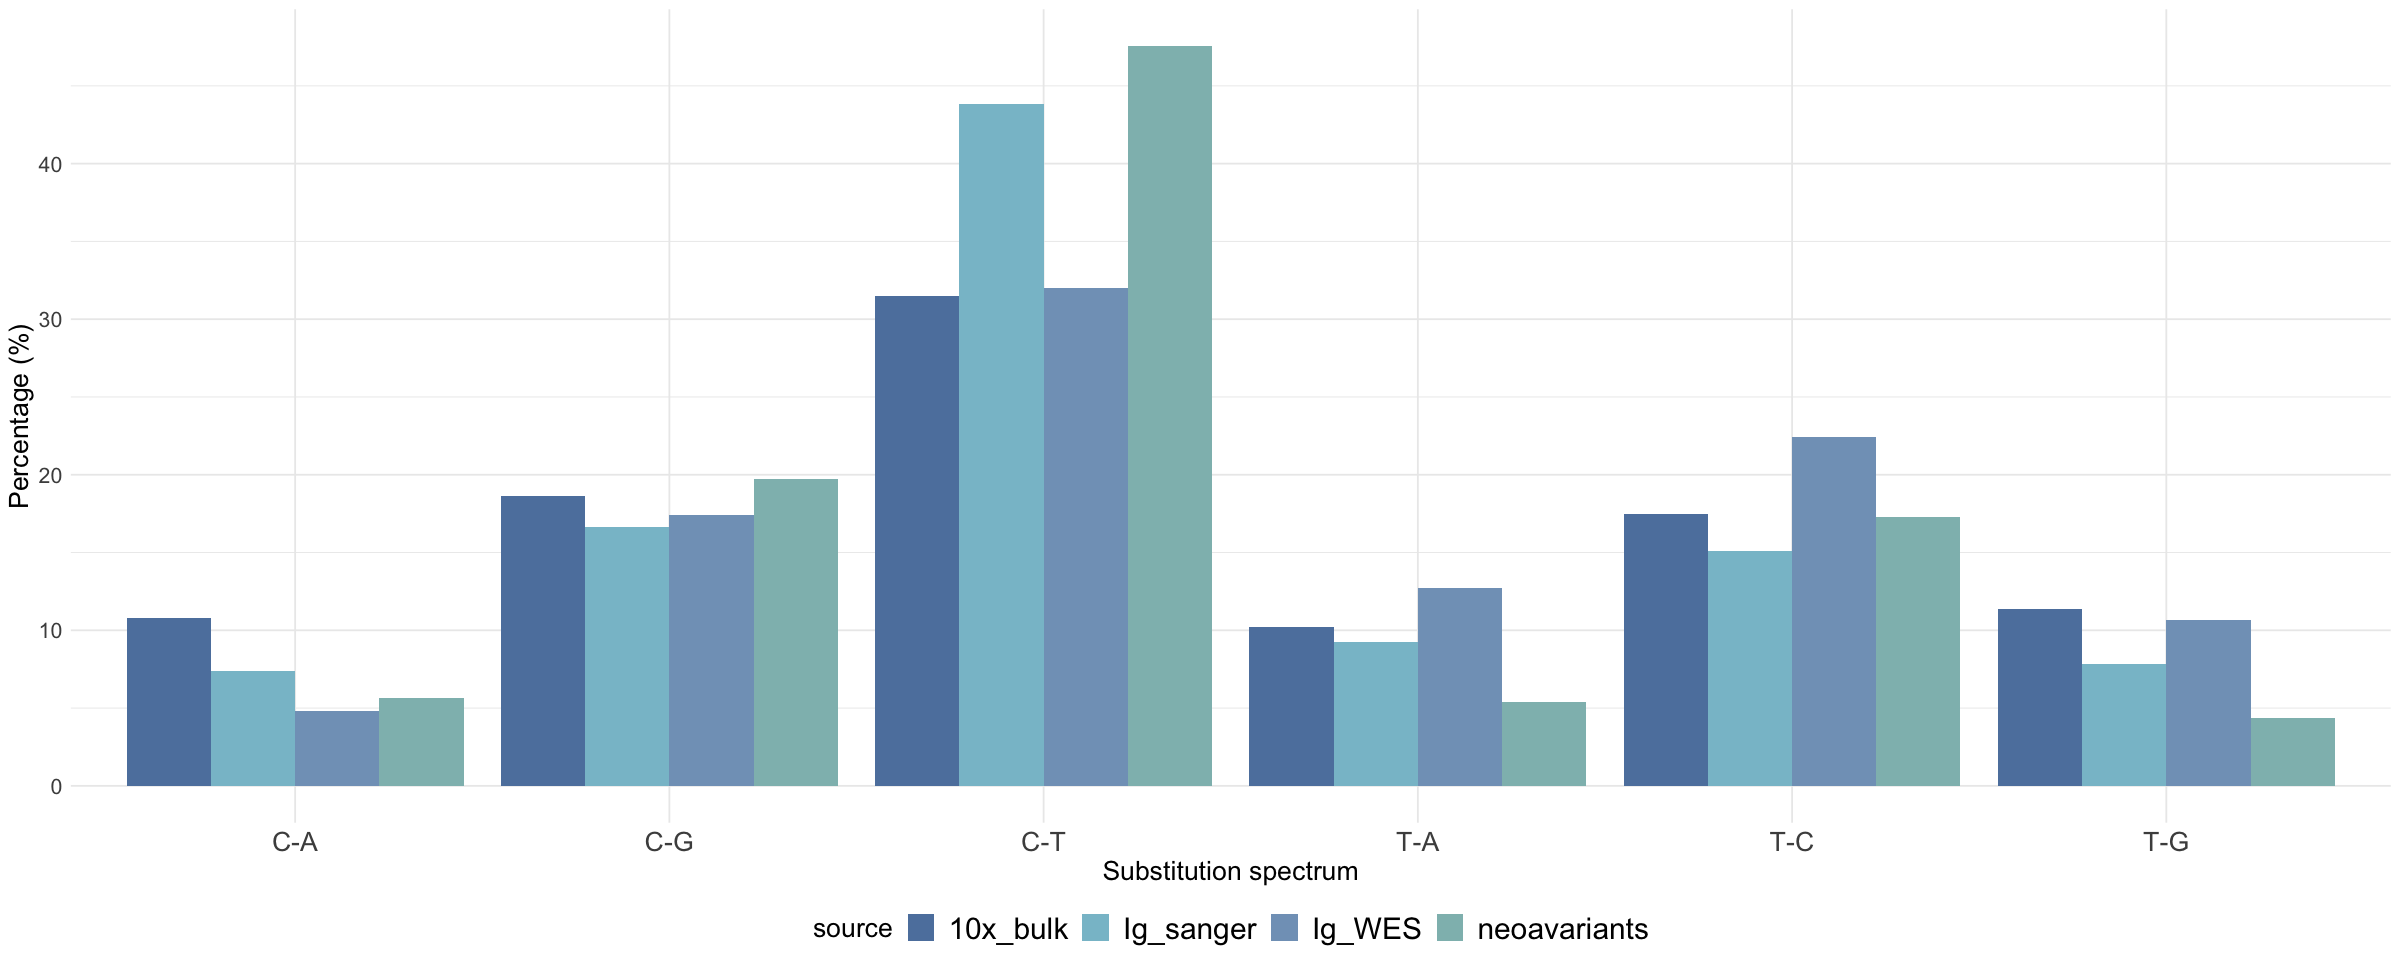

In [25]:
# Using a cool color palette
my_custom_palette <- c("#5E81AC", "#88C0D0", "#81A1C1", "#8FBCBB", "#B48EAD")

# Create bar plot
ggplot(spectro_combine, aes(x = substitution, y = Percentage, fill = source)) +
  geom_bar(stat = "identity", position = position_dodge()) +
  theme_minimal() +
  labs( x = "Substitution spectrum", y = "Percentage (%)") +
  scale_fill_manual(values = my_custom_palette) +  # Use custom color palette
  theme(legend.position = "bottom",
        text = element_text(size = 16),  # Increase general text size
        axis.text.x = element_text(size = 16),  # Increase x-axis label size
        legend.text = element_text(size = 18),  # Increase legend text size
        plot.title = element_text(size = 16, hjust = 0.5))  # Increase title size and center it



In [26]:
WriteXLS::WriteXLS(spectro_combine,
                    "output/substitution_spectrum_aggregated.xlsx" )

In [27]:
# function to perform chi-square test on each group
perform_chisq_test <- function(df) {
  chisq_result <- chisq.test(df$Percentage)$p.value
  return(data.frame(chisq_test_p_value = chisq_result))
}

# Perform the chi-square tests
chi_square_results <- spectro_combine %>% 
  filter(source %in% c("10x_bulk", "neoavariants")) %>% 
  group_by(substitution, source) %>% 
  group_by(substitution) %>% 
  nest() %>% 
  rowwise() %>% 
  summarise(perform_chisq_test(data))

# Print chi-square test results
print(chi_square_results)


`summarise()` has grouped output by 'substitution'. You can override using the `.groups` argument.


# A tibble: 6 × 2
# Groups:   substitution [6]
  substitution chisq_test_p_value
  <chr>                     <dbl>
1 C-A                      0.204 
2 C-G                      0.855 
3 C-T                      0.0714
4 T-A                      0.226 
5 T-C                      0.969 
6 T-G                      0.0777


#### Data for Hendrik (substitution by subject)

In [29]:
spectro_10x <- KBall_subs_subject %>% bind_rows(spectro_subject)

In [30]:
head(spectro_10x)

subject,substitution,n,Percentage,source
<chr>,<chr>,<int>,<dbl>,<chr>
K1B_S10000,C-A,45,10.61321,10x_bulk
K1B_S10000,C-G,83,19.57547,10x_bulk
K1B_S10000,C-T,132,31.13208,10x_bulk
K1B_S10000,T-A,48,11.32075,10x_bulk
K1B_S10000,T-C,67,15.80189,10x_bulk
K1B_S10000,T-G,49,11.55660,10x_bulk


In [31]:
WriteXLS::WriteXLS(spectro_10x,
                    "output/substitution_spectrum_10x.xlsx" )